0,1000,2000,3000,4000,5000,6000,7000,8000,9000,10000,

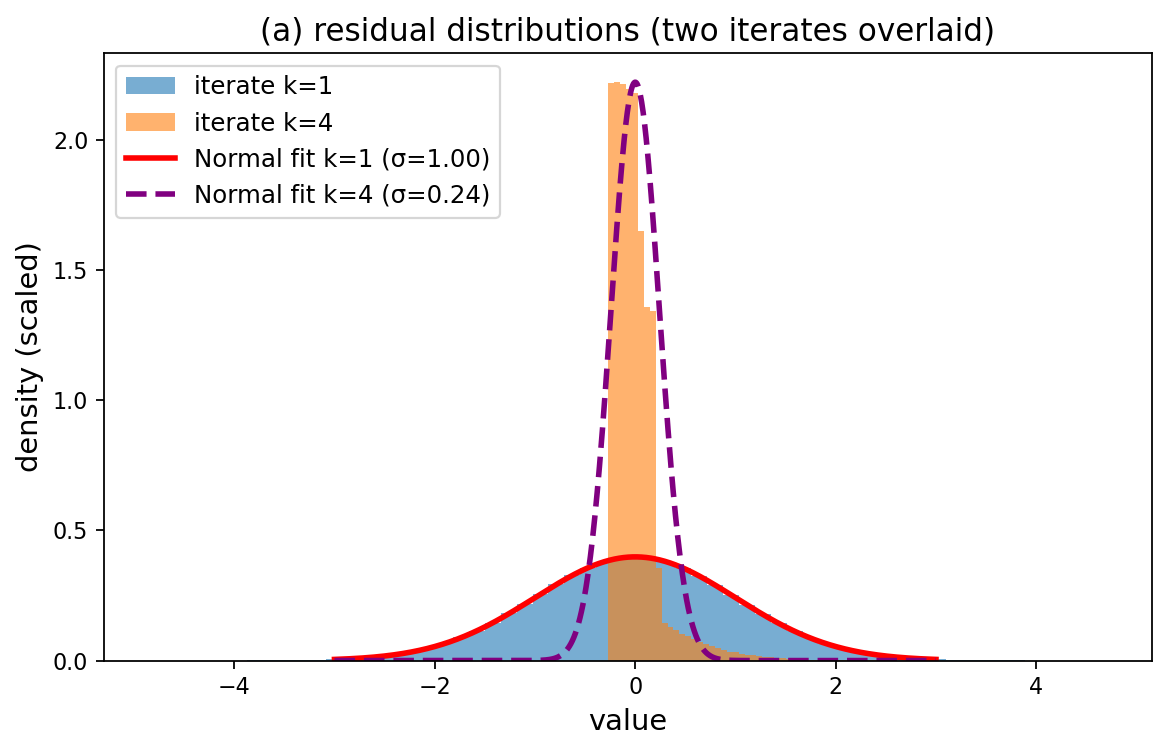

In [15]:
# =============================================================================
# Figure 1: Empirical validation of the iterated-means baseline dynamics
#
# Generates four panels:
#   (a) Residual distributions at iterations k=1 and k=4, overlaid with
#       fitted Gaussians of equal variance, illustrating approximate normality
#       and the geometric contraction by factor eta = sqrt(1 - 2/pi) ~ 0.603.
#   (b) RMSE decay on a log-log scale across n=10001 iterations, compared
#       with the theoretical n^{-1/2} upper bound (Theorem 2.4) and a
#       linear fit to the empirical slope for k in [100, 10001].
#   (c) Shape statistic zeta_k = mu_k^2 / sigma_k^2 on a log-log scale,
#       compared with the theoretical lower bound 1/(k+1) (Theorem 2.4).
#   (d) Bounded statistic (k+1)*zeta_k - 1 on a linear scale for k in
#       [100, 10000], confirming the constant-corridor hypothesis of
#       Theorem 2.5.
#
# Data: N = 10^6 i.i.d. standard normal samples (seed 42 for reproducibility).
# Output: figs/1a.pdf, figs/1b.pdf, figs/1c.pdf, figs/1d.pdf
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm

N = int(1e6)
std = 1
inidist = np.random.normal(0, std, N)
n = 10001
mean = np.zeros(n)
sigma = np.zeros(n)
dist  = inidist - np.mean(inidist)  # r^(1) with zero mean (optional but matches the text)
to_plot = dist
beta = 0
t0 = 1
for i in range(n):
    if (i == 3):
        to_plot = dist
    sigma[i] = np.std(dist)
    mean[i] = np.mean(np.abs(dist))
    dist = np.abs(dist)-mean[i]
    if (i % 1000 == 0):
        print(i, end=',')

# ----------------------------
# 1) Generate data (same as iteration loop)
# ----------------------------
np.random.seed(42)
inidist = np.random.normal(0.0, 1.0, size=N)

mean_arr  = np.zeros(n)
sigma_arr = np.zeros(n)
to_plot_seq = []
dist = inidist - inidist.mean()

for i in range(4):
    to_plot_seq.append(dist.copy())
    sigma_arr[i] = dist.std()
    mean_arr[i]  = np.abs(dist).mean()
    dist = np.abs(dist) - mean_arr[i]

# ----------------------------
# 2) Plotting function with Julia colors
# ----------------------------
def figure_a_python(to_plot_seq, k1=1, k2=4, bins=60, fname="figs/1a.pdf"):
    r1 = to_plot_seq[k1-1]
    r2 = to_plot_seq[k2-1]

    mu1, s1 = r1.mean(), r1.std()
    mu2, s2 = r2.mean(), r2.std()

    smax = max(s1, s2)
    xlo  = min(mu1, mu2) - 3*smax
    xhi  = max(mu1, mu2) + 3*smax
    xs   = np.linspace(xlo, xhi, 800)

    # Julia default palette colors
    col1 = "#1f77b4"   # blue
    col2 = "#ff7f0e"   # orange

    plt.figure(figsize=(7.4, 4.8), dpi=160)

    # histograms
    plt.hist(r1, bins=bins, density=True, alpha=0.6, color=col1, label=f"iterate k={k1}")
    plt.hist(r2, bins=bins, density=True, alpha=0.6, color=col2, label=f"iterate k={k2}")

    # scale PDFs to match histogram peaks
    def scaled_pdf(r, mu, sigma):
        counts, _ = np.histogram(r, bins=bins, density=True)
        peak = counts.max()
        pdf_vals = norm.pdf(xs, mu, sigma)
        return pdf_vals * (peak / pdf_vals.max() if pdf_vals.max() > 0 else 1.0)

    # overlay normal fits in matching colors
    plt.plot(xs, scaled_pdf(r1, mu1, s1), lw=2.5, color="red",
             label=f"Normal fit k={k1} (σ={s1:.2f})")
    plt.plot(xs, scaled_pdf(r2, mu2, s2), lw=2.5, ls="--", color="purple",
             label=f"Normal fit k={k2} (σ={s2:.2f})")

    # labels and legend
    plt.xlabel("value", fontsize=13)
    plt.ylabel("density (scaled)", fontsize=13)
    plt.title("(a) residual distributions (two iterates overlaid)", fontsize=14)
    plt.legend(loc="upper left", fontsize=11, frameon=True)
    plt.tight_layout()
    plt.savefig(fname, dpi=600, bbox_inches="tight")
    plt.show()

# ----------------------------
# 3) Call it
# ----------------------------
figure_a_python(to_plot_seq, k1=1, k2=4)

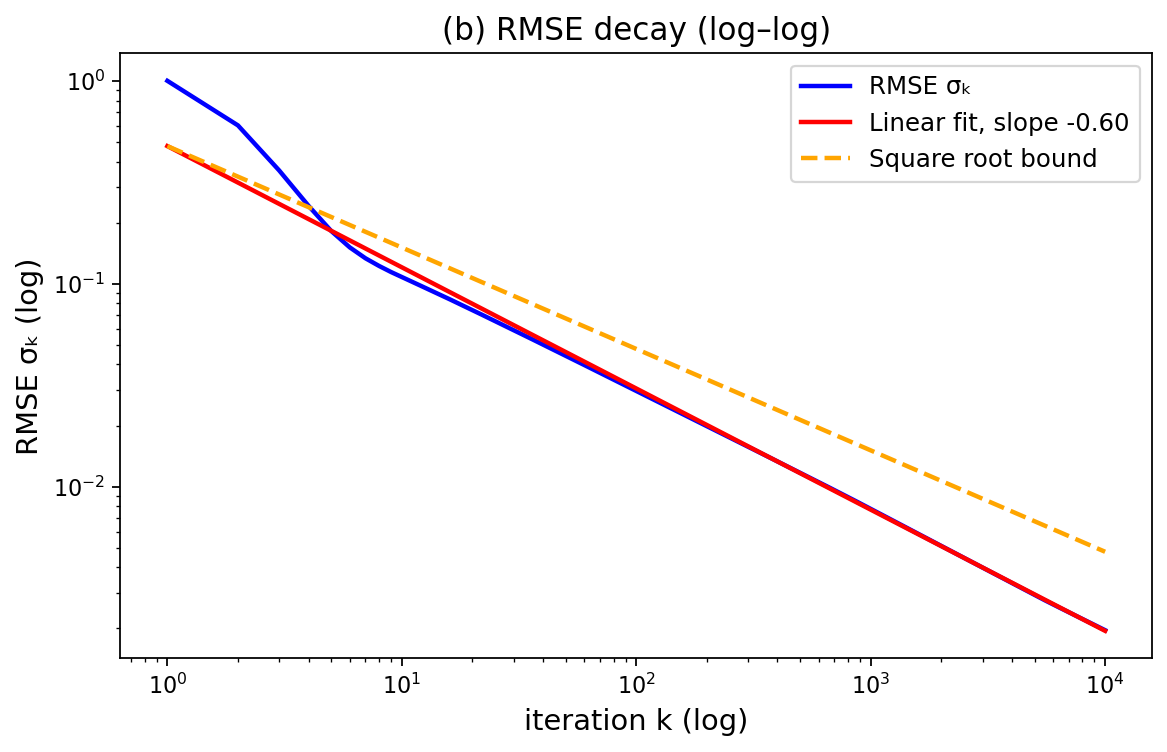

In [13]:
slope, intercept, r, p, se = stats.linregress(np.log(range(100, n+1)), np.log(sigma[99:]))
slope, intercept, r, p, se

def figure_b_python(sigma_arr, slope, intercept, fname="figs/1b.pdf"):
    n = len(sigma_arr)
    kgrid = np.arange(1, n+1)

    # Julia palette
    col_main = "blue"   # blue
    col_fit  = "red"
    col_ref  = "orange"   # orange

    plt.figure(figsize=(7.4, 4.8), dpi=160)

    # main RMSE line (blue)
    plt.plot(kgrid, sigma_arr, lw=2.0, color=col_main, label="RMSE σₖ")

    # fitted slope line in log–log coords
    plt.plot(kgrid, np.exp(slope*np.log(kgrid)+intercept),
             lw=2.0, color=col_fit, label=f"Linear fit, slope {slope:.2f}")

    # square-root bound line
    plt.plot(kgrid, np.exp(-0.5*np.log(kgrid)+intercept),
             lw=2.0, color=col_ref, ls="--", label="Square root bound")

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("iteration k (log)", fontsize=13)
    plt.ylabel("RMSE σₖ (log)", fontsize=13)
    plt.title("(b) RMSE decay (log–log)", fontsize=14)
    plt.legend(loc="upper right", fontsize=11, frameon=True)
    plt.tight_layout()
    plt.savefig(fname, dpi=600, bbox_inches="tight")
    plt.show()

figure_b_python(sigma, slope=slope, intercept=intercept)

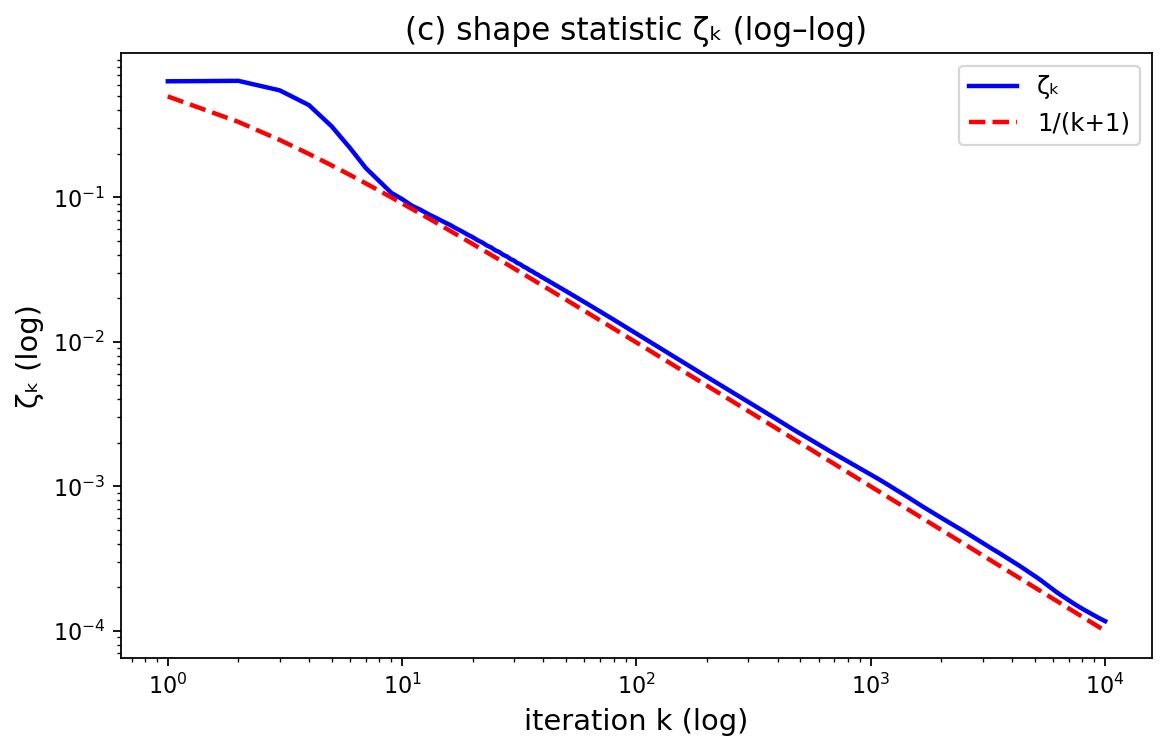

In [14]:
def figure_c_python(mean_arr, sigma_arr, fname="figs/1c.pdf"):
    n = len(mean_arr)
    kgrid = np.arange(1, n+1)
    zeta = (mean_arr**2) / (sigma_arr**2)
    lower = 1.0 / (kgrid + 1.0)

    # Julia palette
    col_main = "blue"   # blue
    col_ref  = "red"   # orange

    plt.figure(figsize=(7.4, 4.8), dpi=160)
    plt.plot(kgrid, zeta, lw=2.0, color=col_main, label="ζₖ")
    plt.plot(kgrid, lower, lw=2.0, ls="--", color=col_ref, label="1/(k+1)")

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("iteration k (log)", fontsize=13)
    plt.ylabel("ζₖ (log)", fontsize=13)
    plt.title("(c) shape statistic ζₖ (log–log)", fontsize=14)
    plt.legend(loc="upper right", fontsize=11, frameon=True)
    plt.tight_layout()
    plt.savefig(fname, dpi=600, bbox_inches="tight")
    plt.show()

# Assuming you already have mean_arr, sigma_arr from the iteration loop
figure_c_python(mean, sigma)

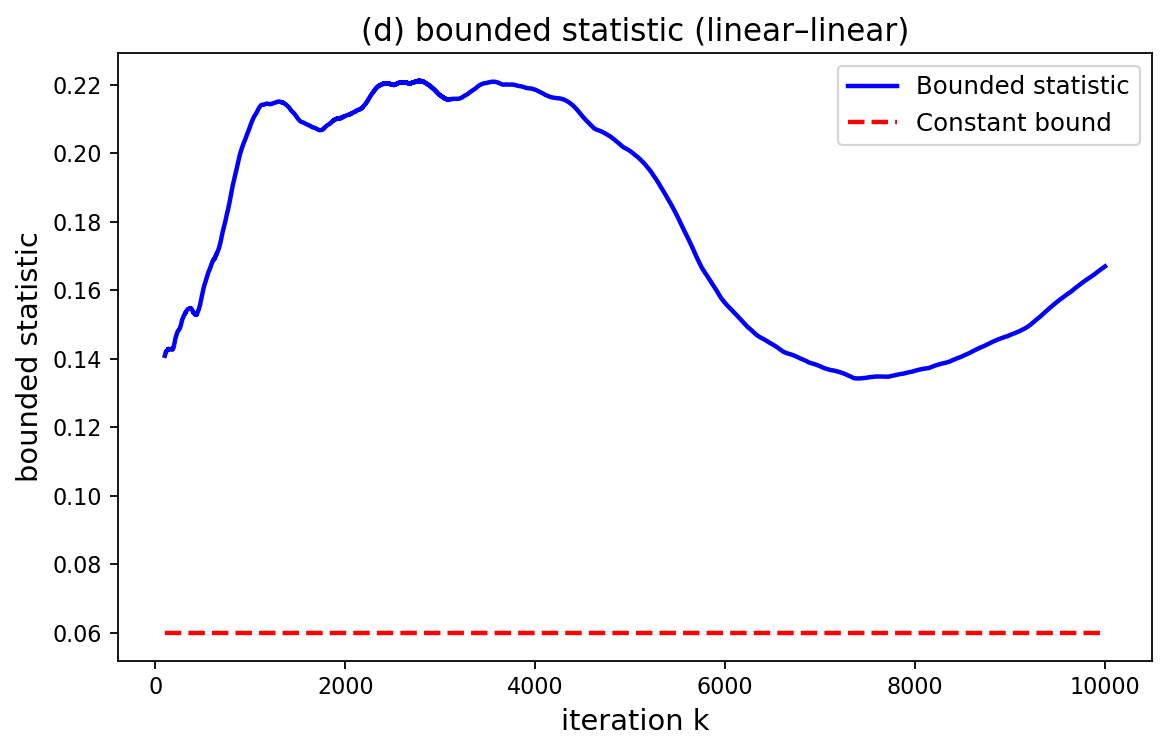

In [12]:
ratio = (mean/sigma)**2
aux = np.array([ratio[i]*(i+1)-1 for i in range(n)])

def figure_d_python(ratio, fname="figs/1d.pdf"):
    n = len(ratio)
    kgrid = np.arange(1, n+1)

    lw = 100   # burn-in to skip first iterations
    up = 10000

    # Julia palette
    col_main = "blue"   # blue
    col_ref  = "red"   # orange

    plt.figure(figsize=(7.4, 4.8), dpi=160)

    # main bounded statistic
    plt.plot(kgrid[lw:up], aux[lw:up],
             lw=2.0, color=col_main, label="Bounded statistic")

    # constant bound line
    plt.plot(kgrid[lw:up], np.full(up-lw, 6e-2),
             lw=2.0, color=col_ref, ls="--", label="Constant bound")

    plt.xscale("linear")
    plt.yscale("linear")
    plt.xlabel("iteration k", fontsize=13)
    plt.ylabel("bounded statistic", fontsize=13)
    plt.title("(d) bounded statistic (linear–linear)", fontsize=14)
    plt.legend(loc="upper right", fontsize=11, frameon=True)
    plt.tight_layout()
    plt.savefig(fname, dpi=600, bbox_inches="tight")
    plt.show()
figure_d_python(aux)